In [1]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from skimage import io, transform
from sklearn import preprocessing
import numpy as np
import joblib
import cv2
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,VotingClassifier


In [3]:
path = r"C:\Users\Lenovo\OneDrive\Desktop\miniproject\Scientific Image Classification"
model_folder = "model"
categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
categories

['Blot-Gel', 'Histopathology', 'X-Ray']

In [5]:
X_file = os.path.join(model_folder, "X.txt.npy")
Y_file = os.path.join(model_folder, "Y.txt.npy")
if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)
    Y = np.load(Y_file)
    print("X and Y arrays loaded successfully.")
else:
    X = [] # input array
    Y = [] # output array
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            print(f'Loading category: {dirs}')
            print(name+" "+root+"/"+directory[j])
            if 'Thumbs.db' not in directory[j]:
                img_array = cv2.imread(root+"/"+directory[j])
                img_resized = resize(img_array, (64, 64, 3))
                # Append the input image array to X
                X.append(img_resized.flatten())
                # Append the index of the category in categories list to Y
                Y.append(categories.index(name))
    X = np.array(X)
    Y = np.array(Y)

    np.save(X_file, X)
    np.save(Y_file, Y)

X and Y arrays loaded successfully.


In [6]:
# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.20,random_state=77)

In [7]:
accuracy=[]
precision = []
recall = []
fscore = []
# Overall metrics table
overall_results = []

# Class-wise metrics table
classwise_results = []

In [8]:
def calculateMetrics(algorithm, predict, testY, labels):

    # Overall metrics
    a = accuracy_score(testY, predict) * 100
    p = precision_score(testY, predict, average='macro') * 100
    r = recall_score(testY, predict, average='macro') * 100
    f = f1_score(testY, predict, average='macro') * 100

    # Save overall metrics
    overall_results.append({
        "Algorithm": algorithm,
        "Accuracy (%)": a,
        "Precision (%)": p,
        "Recall (%)": r,
        "F1 Score (%)": f
    })

    print(f"{algorithm} Accuracy: {a:.2f}")
    print(f"{algorithm} Precision: {p:.2f}")
    print(f"{algorithm} Recall: {r:.2f}")
    print(f"{algorithm} F1 Score: {f:.2f}\n")

    # Classification report & confusion matrix
    report = classification_report(testY, predict, target_names=labels, output_dict=True)
    conf_matrix = confusion_matrix(testY, predict)

    # Class-wise accuracy
    class_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)

    print(f"{algorithm} Class-wise Metrics:")
    print(f"{'Class':<12}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1 Score':<12}")

    for i, class_name in enumerate(labels):
        acc = class_accuracy[i] * 100
        prec = report[class_name]['precision'] * 100
        rec = report[class_name]['recall'] * 100
        f1 = report[class_name]['f1-score'] * 100

        print(f"{class_name:<12}{acc:<12.2f}{prec:<12.2f}{rec:<12.2f}{f1:<12.2f}")

        # Save class-wise metrics
        classwise_results.append({
            "Algorithm": algorithm,
            "Class": class_name,
            "Accuracy (%)": acc,
            "Precision (%)": prec,
            "Recall (%)": rec,
            "F1 Score (%)": f1
        })

    # Confusion matrix plot
    plt.figure(figsize=(5, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{algorithm} Confusion Matrix")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


Multinomial NBC Accuracy: 95.67
Multinomial NBC Precision: 95.78
Multinomial NBC Recall: 95.74
Multinomial NBC F1 Score: 95.70

Multinomial NBC Class-wise Metrics:
Class       Accuracy    Precision   Recall      F1 Score    
Blot-Gel    94.29       94.29       94.29       94.29       
Histopathology100.00      94.12       100.00      96.97       
X-Ray       92.93       98.92       92.93       95.83       


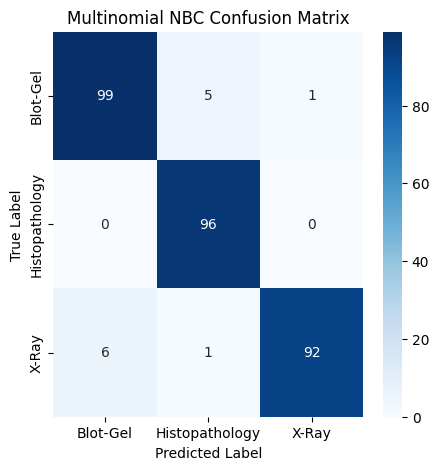

In [9]:
# Check if the pkl file exists
Model_file = os.path.join(model_folder, "Multi_NBC_Model.pkl")
if os.path.exists(Model_file):
    # Load the model from the pkl file
    nb_classifier = joblib.load(Model_file)
    y_pred = nb_classifier.predict(x_test)
    calculateMetrics("Multinomial NBC", y_pred, y_test, categories)
else:
    # Create a Gaussian Naive Bayes classifier
    nb_classifier = MultinomialNB()
    # Train the classifier on the training data
    nb_classifier.fit(x_train, y_train)
    # Save the model weights to a pkl file
    joblib.dump(nb_classifier, Model_file)  
    y_pred = nb_classifier.predict(x_test)
    calculateMetrics("Multinomial NBC", y_pred, y_test, categories)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Gaussian NBC Accuracy: 90.33
Gaussian NBC Precision: 90.32
Gaussian NBC Recall: 90.51
Gaussian NBC F1 Score: 90.32

Gaussian NBC Class-wise Metrics:
Class       Accuracy    Precision   Recall      F1 Score    
Blot-Gel    81.90       89.58       81.90       85.57       
Histopathology90.62       85.29       90.62       87.88       
X-Ray       98.99       96.08       98.99       97.51       


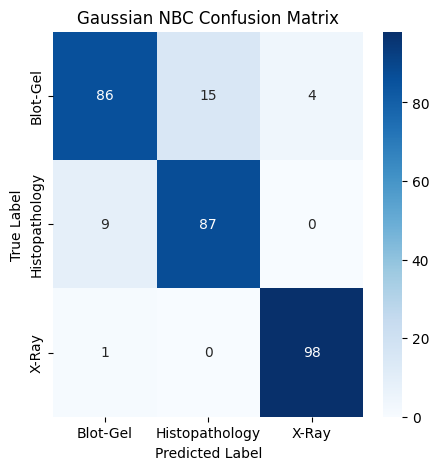

In [11]:
# Check if the pkl file exists
Model_file = os.path.join(model_folder, "Gaussian_NBC_Model.pkl")
if os.path.exists(Model_file):
    nb_classifier = joblib.load(Model_file)
    y_pred = nb_classifier.predict(x_test)
    calculateMetrics("Gaussian NBC", y_pred, y_test, categories)
else:
    nb_classifier = GaussianNB()
    nb_classifier.fit(x_train, y_train)
    joblib.dump(nb_classifier, Model_file)  
    y_pred = nb_classifier.predict(x_test)
    calculateMetrics("Gaussian NBC", y_pred, y_test, categories)

RFC Accuracy: 99.33
RFC Precision: 99.34
RFC Recall: 99.32
RFC F1 Score: 99.33

RFC Class-wise Metrics:
Class       Accuracy    Precision   Recall      F1 Score    
Blot-Gel    100.00      99.06       100.00      99.53       
Histopathology98.96       98.96       98.96       98.96       
X-Ray       98.99       100.00      98.99       99.49       


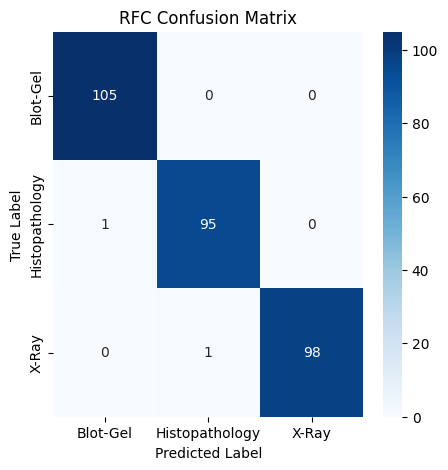

In [12]:
# Check if the pkl file exists
Model_file = os.path.join(model_folder, "RFC_Model.pkl")
if os.path.exists(Model_file):
    RFC = joblib.load(Model_file)
    y_pred = RFC.predict(x_test)
    calculateMetrics("RFC", y_pred, y_test, categories)
else:
    RFC = RandomForestClassifier()
    RFC.fit(x_train, y_train)
    joblib.dump(RFC, Model_file)  
    y_pred = RFC.predict(x_test)
    calculateMetrics("RFC", y_pred, y_test, categories)

In [13]:
overall_df = pd.DataFrame(overall_results)
overall_df


,Algorithm,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Multinomial NBC,95.666667,95.776031,95.738336,95.696248
1,Gaussian NBC,90.333333,90.318627,90.506554,90.321122
2,RFC,99.333333,99.338312,99.316077,99.325595


In [14]:
classwise_df = pd.DataFrame(classwise_results)
classwise_df


,Algorithm,Class,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Multinomial NBC,Blot-Gel,94.285714,94.285714,94.285714,94.285714
1,Multinomial NBC,Histopathology,100.000000,94.117647,100.000000,96.969697
2,Multinomial NBC,X-Ray,92.929293,98.924731,92.929293,95.833333
3,Gaussian NBC,Blot-Gel,81.904762,89.583333,81.904762,85.572139
4,Gaussian NBC,Histopathology,90.625000,85.294118,90.625000,87.878788
5,Gaussian NBC,X-Ray,98.989899,96.078431,98.989899,97.512438
6,RFC,Blot-Gel,100.000000,99.056604,100.000000,99.526066
7,RFC,Histopathology,98.958333,98.958333,98.958333,98.958333
8,RFC,X-Ray,98.989899,100.000000,98.989899,99.492386


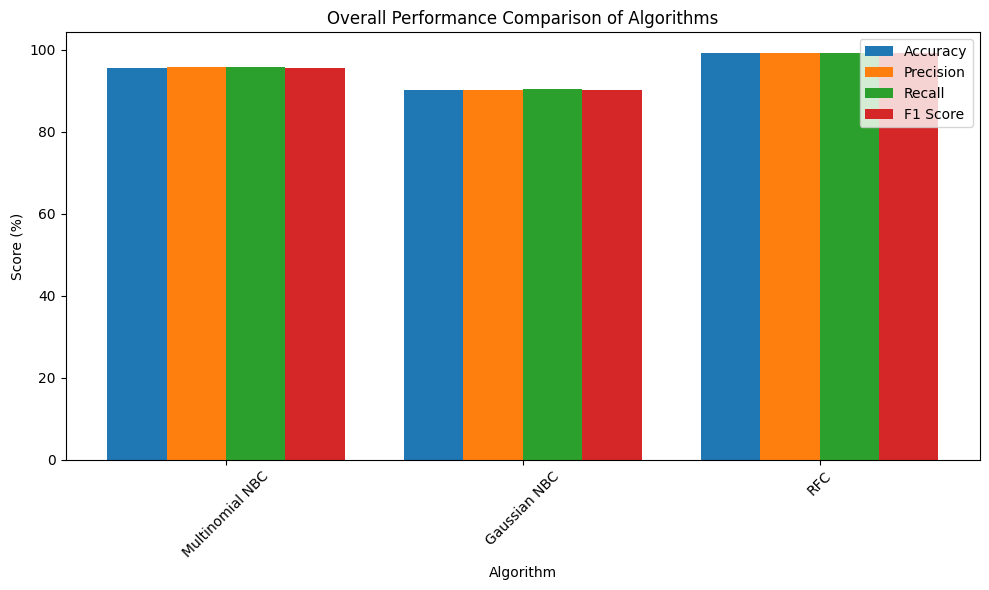

In [15]:
import numpy as np

# X locations
x = np.arange(len(overall_df['Algorithm']))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, overall_df['Accuracy (%)'], width, label='Accuracy')
plt.bar(x - 0.5*width, overall_df['Precision (%)'], width, label='Precision')
plt.bar(x + 0.5*width, overall_df['Recall (%)'], width, label='Recall')
plt.bar(x + 1.5*width, overall_df['F1 Score (%)'], width, label='F1 Score')

plt.xticks(x, overall_df['Algorithm'], rotation=45)
plt.xlabel("Algorithm")
plt.ylabel("Score (%)")
plt.title("Overall Performance Comparison of Algorithms")
plt.legend()
plt.tight_layout()
plt.show()


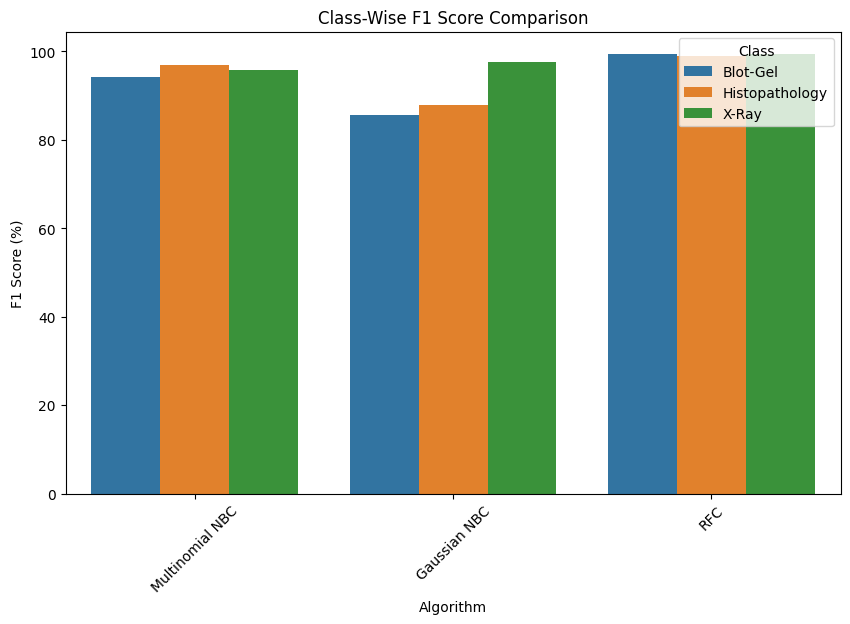

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=classwise_df,
    x="Algorithm",
    y="F1 Score (%)",
    hue="Class"
)
plt.title("Class-Wise F1 Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=45)
plt.legend(title="Class")
plt.show()


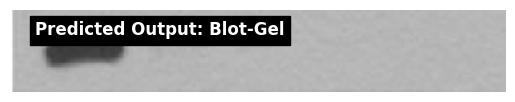

In [17]:
path=r"C:\Users\Lenovo\OneDrive\Desktop\miniproject\Scientific Image Classification\Blot-Gel\010208.png"
img=imread(path)
img_resize=resize(img,(64,64,3))
img_preprocessed=[img_resize.flatten()]
output_number=RFC.predict(img_preprocessed)[0]
output_name=categories[output_number]

plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='white', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()

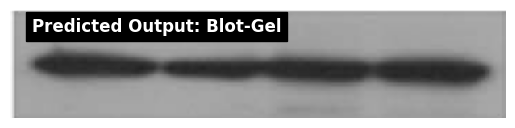

In [18]:
path=r"C:\Users\Lenovo\OneDrive\Desktop\miniproject\Scientific Image Classification\Blot-Gel\010300 (4).png"
img=imread(path)
img_resize=resize(img,(64,64,3))
img_preprocessed=[img_resize.flatten()]
output_number=RFC.predict(img_preprocessed)[0]
output_name=categories[output_number]

plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='white', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()

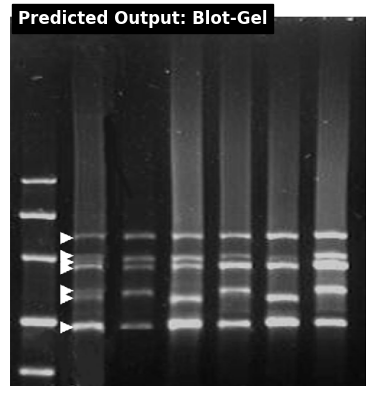

In [19]:
path=r"C:\Users\Lenovo\OneDrive\Desktop\miniproject\Scientific Image Classification\Blot-Gel\020000 (5).png"
img=imread(path)
img_resize=resize(img,(64,64,3))
img_preprocessed=[img_resize.flatten()]
output_number=RFC.predict(img_preprocessed)[0]
output_name=categories[output_number]

plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='white', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()

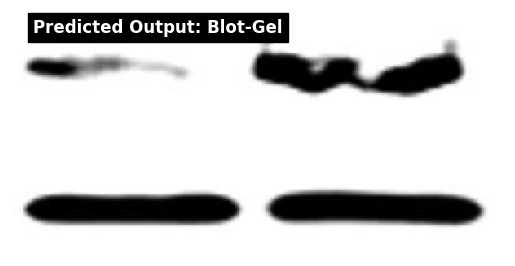

In [20]:
path=r"C:\Users\Lenovo\OneDrive\Desktop\miniproject\Scientific Image Classification\Blot-Gel\020000 (24).png"
img=imread(path)
img_resize=resize(img,(64,64,3))
img_preprocessed=[img_resize.flatten()]
output_number=RFC.predict(img_preprocessed)[0]
output_name=categories[output_number]

plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='white', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()

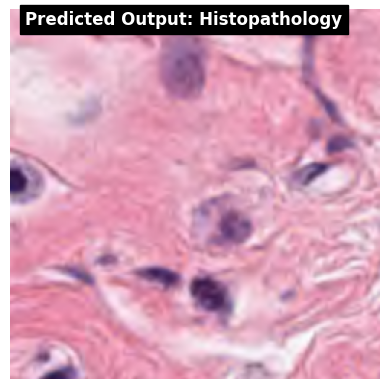

In [21]:
path=r"C:\Users\Lenovo\OneDrive\Desktop\miniproject\Scientific Image Classification\Histopathology\image_102 (2).png"
img=imread(path)
img_resize=resize(img,(64,64,3))
img_preprocessed=[img_resize.flatten()]
output_number=RFC.predict(img_preprocessed)[0]
output_name=categories[output_number]

plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='white', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()

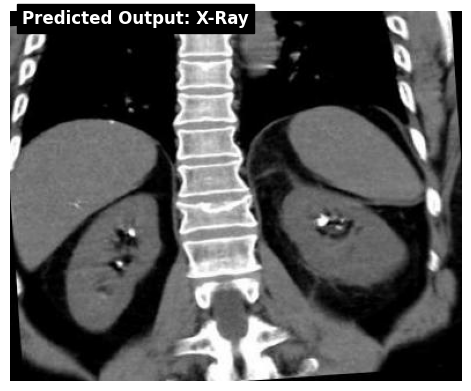

In [22]:
path=r"C:\Users\Lenovo\OneDrive\Desktop\miniproject\Scientific Image Classification\X-Ray\1-3-46-670589-33-1-63706641772798806900001-5070752803903512964_png_jpg.rf.905378ff6f749cb0c7cd1a34658f1fb5.jpg"
img=imread(path)
img_resize=resize(img,(64,64,3))
img_preprocessed=[img_resize.flatten()]
output_number=RFC.predict(img_preprocessed)[0]
output_name=categories[output_number]

plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='white', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()